In [42]:
# Run garbage collection
import gc
gc.collect()

28834

In [43]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter
from sklearn.preprocessing import StandardScaler


In [44]:
import scipy.signal as signal
def filter_signal(signal_data, axis=0, fs=100, lowcut=0.5, highcut=45.0, notch_freq=50.0, Q=30.0):
        nyquist = 0.5 * fs
        low = lowcut / nyquist
        high = highcut / nyquist
        b, a = signal.butter(4, [low, high], btype='band')
        notch_b, notch_a = signal.iirnotch(notch_freq / nyquist, Q)
        filtered_signal = signal.filtfilt(b, a, signal_data, axis=axis)
        filtered_signal = signal.filtfilt(notch_b, notch_a, filtered_signal, axis=axis)
        return filtered_signal

In [45]:
def normalize_data_z_score(data: np.ndarray) -> np.ndarray:
    num_samples, sample_length, num_channels = data.shape
    data_reshaped = data.reshape(-1, num_channels)
    scaler = StandardScaler()
    data_normalized = scaler.fit_transform(data_reshaped)
    return data_normalized.reshape(num_samples, sample_length, num_channels)

In [46]:
path_load = './data_source_sub'


##train
X_train = np.load(os.path.join(path_load, 'Y_train.npy'))
X_train = normalize_data_z_score(X_train)
X_train = filter_signal(X_train, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_train = pd.read_csv(os.path.join(path_load, 'Z_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])
y_train = y_train.to_numpy(dtype=np.float32)

z_train = pd.read_csv(os.path.join(path_load, 'T_train.csv'))
z_train = z_train.drop(columns=['ecg_id'])
z_train = z_train.to_numpy(dtype=np.float32)

##test
X_test = np.load(os.path.join(path_load, 'Y_test.npy'))
X_test = normalize_data_z_score(X_test)
X_test = filter_signal(X_test, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_test = pd.read_csv(os.path.join(path_load, 'Z_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])
y_test = y_test.to_numpy(dtype=np.float32)

z_test = pd.read_csv(os.path.join(path_load, 'T_test.csv'))
z_test = z_test.drop(columns=['ecg_id'])
z_test = z_test.to_numpy(dtype=np.float32)

##validation
X_val = np.load(os.path.join(path_load, 'Y_valid.npy'))
X_val = normalize_data_z_score(X_val)
X_val = filter_signal(X_val, axis=1, fs=100, lowcut=0.5, highcut=45.0)

y_val = pd.read_csv(os.path.join(path_load, 'Z_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])
y_val = y_val.to_numpy(dtype=np.float32)

z_val = pd.read_csv(os.path.join(path_load, 'T_valid.csv'))
z_val = z_val.drop(columns=['ecg_id'])
z_val = z_val.to_numpy(dtype=np.float32)

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["z_train", z_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["z_test", z_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
    ["z_val", z_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| z_train   | (17418, 23)       |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| z_test    | (2198, 23)        |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+
| z_val     | (2183, 23)        |
+-----------+-------------------+


In [74]:
classes = 0
indices = np.where(y_test[:, classes] == 1.0)[0]
index = np.random.choice(indices)

In [69]:
from ecg_analysis import *

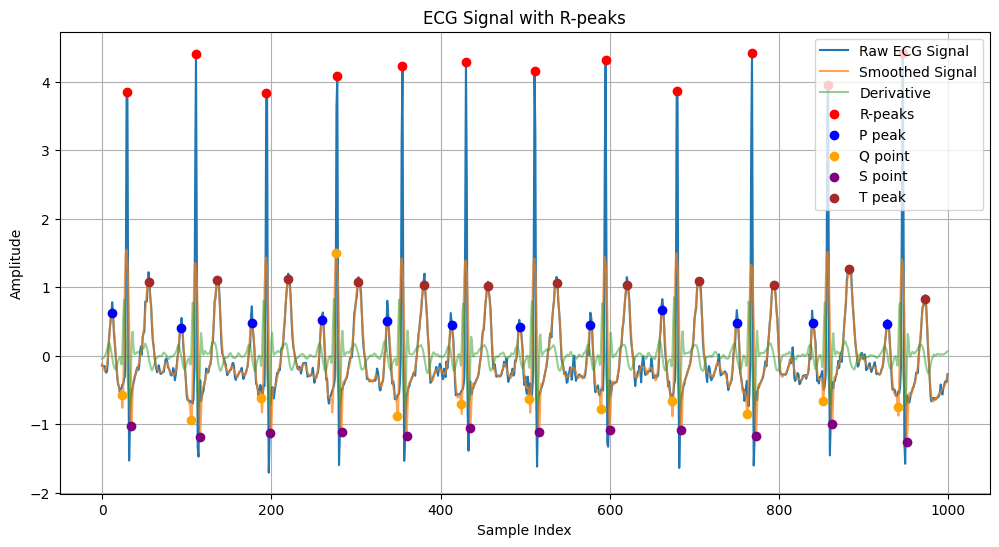

In [99]:
classes = 0
indices = np.where(y_test[:, classes] == 1.0)[0]
index = np.random.choice(indices)
ecg = X_test[index, :, :]
ecg_leadII = ecg[:, 1]

r_peaks = detect_r_peaks(ecg_leadII, fs=100, plot=False)[0]
ecg_beats = segment_ECG_beats(ecg, r_peaks, plot={"plot": False, "lead": "All"})[1]
intervals = detect_pqst(ecg_leadII, r_peaks, fs=100, plot=True)

converted_intervals = convert_to_beat_index(intervals)

{'P': [np.int64(23), np.int64(4), np.int64(8), np.int64(12), np.int64(14), np.int64(27), np.int64(22), np.int64(19), np.int64(28), np.int64(26), np.int64(6), np.int64(13), np.int64(28), np.int64(4)], 'Q': [np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34), np.int64(34)], 'R': [np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40), np.int64(40)], 'S': [np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45), np.int64(45)], 'T': [np.int64(73), np.int64(77), np.int64(83), np.int64(80), np.int64(84), np.int64(84), np.int64(81), np.int64(80), np.int64(84), np.int64(81), np.int64(84), np.int64(82), np.int64(78), np.

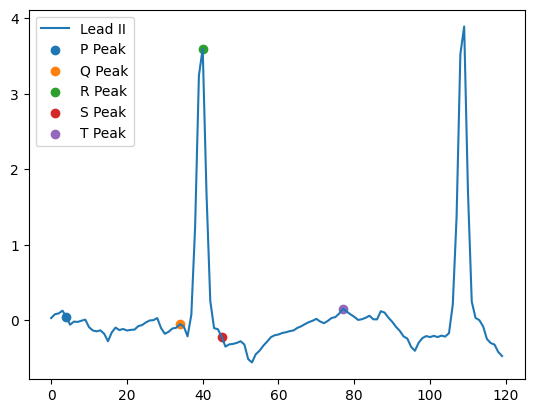

In [73]:
print(converted_intervals)

k, v = next(iter(converted_intervals.items()))
print(len(v ))
print(ecg_beats.shape)
beat_index = 1
beat = ecg_beats[1, beat_index, :]  # Example beat from Lead II
x = np.arange(len(beat))   # sample indices (0, 1, 2, ...)
plt.plot(x, beat, label='Lead II')

kP, vP = list(converted_intervals.items())[0]
kQ, vQ = list(converted_intervals.items())[1]
kR, vR = list(converted_intervals.items())[2]
kS, vS = list(converted_intervals.items())[3]
kT, vT = list(converted_intervals.items())[4]
plt.scatter(vP[beat_index], beat[vP[beat_index]], label=f'{kP} Peak')
plt.scatter(vQ[beat_index], beat[vQ[beat_index]], label=f'{kQ} Peak')
plt.scatter(vR[beat_index], beat[vR[beat_index]], label=f'{kR} Peak')
plt.scatter(vS[beat_index], beat[vS[beat_index]], label=f'{kS} Peak')
plt.scatter(vT[beat_index], beat[vT[beat_index]], label=f'{kT} Peak')
plt.legend()
plt.show()